In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load Dataset

In [26]:
df = pd.read_csv("data/train.csv")

### Data cleaning

In [27]:
df.info

<bound method DataFrame.info of         Store  Dept        Date  Weekly_Sales  IsHoliday
0           1     1  2010-02-05      24924.50      False
1           1     1  2010-02-12      46039.49       True
2           1     1  2010-02-19      41595.55      False
3           1     1  2010-02-26      19403.54      False
4           1     1  2010-03-05      21827.90      False
...       ...   ...         ...           ...        ...
421565     45    98  2012-09-28        508.37      False
421566     45    98  2012-10-05        628.10      False
421567     45    98  2012-10-12       1061.02      False
421568     45    98  2012-10-19        760.01      False
421569     45    98  2012-10-26       1076.80      False

[421570 rows x 5 columns]>

In [28]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
df['Date'] = pd.to_datetime(df['Date'])

# EDA

### Sales trend

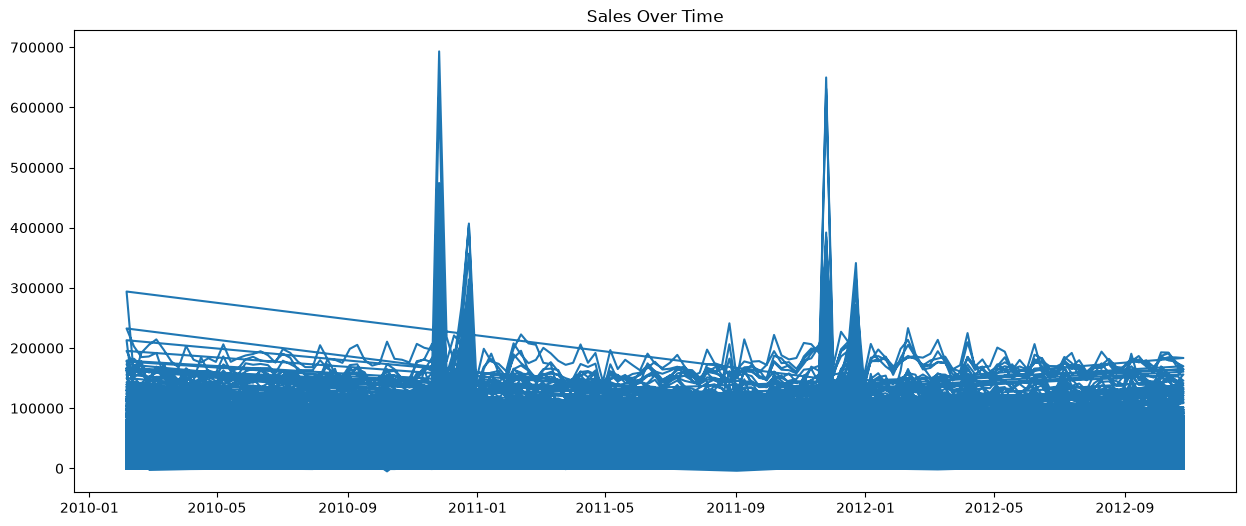

In [31]:
plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Weekly_Sales'])
plt.title("Sales Over Time")
plt.show()

### Monthly Sales

<Axes: xlabel='Date'>

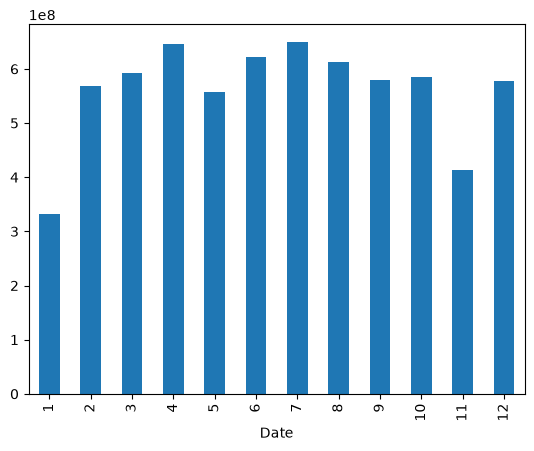

In [32]:
monthly = df.groupby(df['Date'].dt.month)['Weekly_Sales'].sum()
monthly.plot(kind = "bar")

### Highest sales store

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

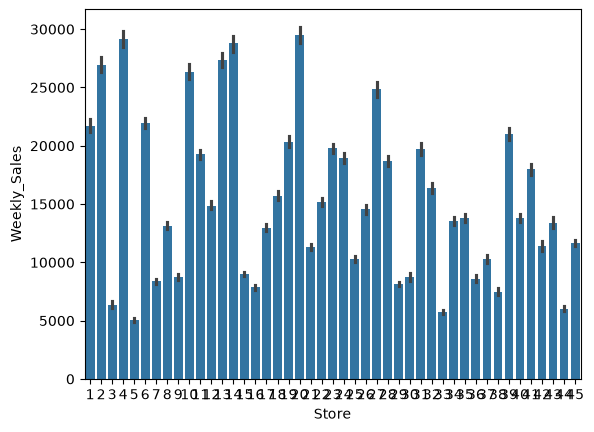

In [33]:
sns.barplot(data = df, x = 'Store', y = 'Weekly_Sales')

### Correlation Heatmap

<Axes: >

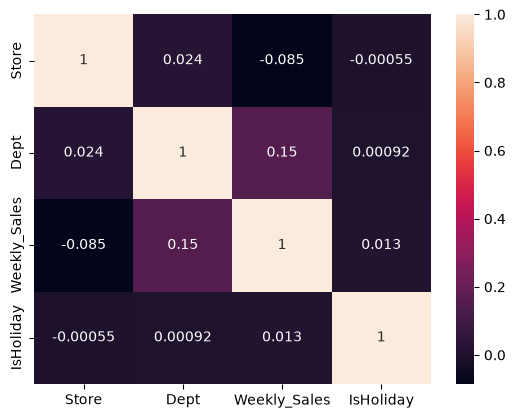

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Feature Engineering
##### Create
* Year
* Month
* Day
* Week
* Quarter

In [35]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

### Prepare Data

In [36]:
x = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales']

#### Split

In [37]:
X_train,X_test,y_train,y_test=train_test_split(
x,
y,
test_size=0.2,
random_state=42
)

### Model Building

In [38]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ -156.71, 111.74, 609.63,..., -12.83, -30.61,-1283.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Store','Dept','IsHoliday',...,'Day','Week','Quarter']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.404e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


### Predicition

In [39]:
pred_lr = lr.predict(X_train)

### XGBoost Model

In [46]:
from xgboost import XGBRegressor
import time

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",
    random_state=42
)

start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time = time.time() - start_time

pred_xgb = xgb_model.predict(X_test)

print("XGBoost GPU training completed")
print("Training Time:", round(training_time, 2), "seconds")

XGBoost GPU training completed
Training Time: 2.77 seconds


### Evaluation

#### MAE

In [41]:
mae_xgb = mean_absolute_error(y_test, pred_xgb)

print("XGBoost MAE:", mae_xgb)

XGBoost MAE: 3458.8716741661474


#### RMSE

In [42]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 5874.406091272949


In [43]:
print ("MAE", mae_xgb)
print ("RMSE", rmse_xgb)

MAE 3458.8716741661474
RMSE 5874.406091272949


### Actual VS Predicted

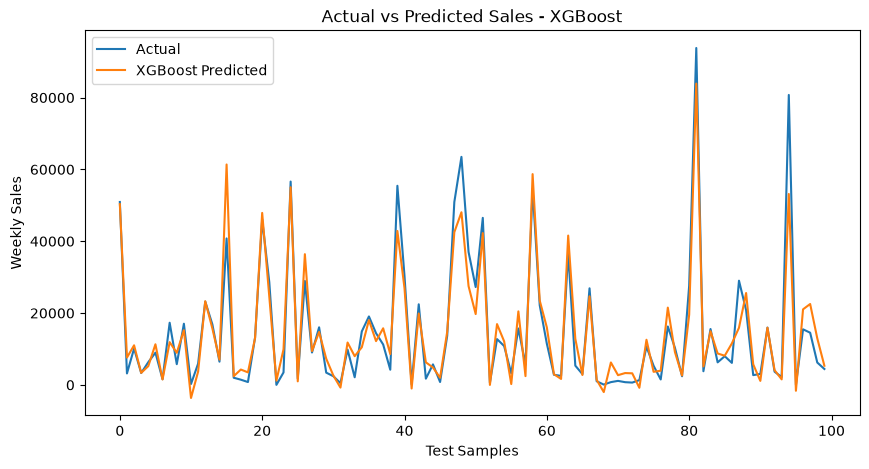

In [44]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(pred_xgb[:100], label="XGBoost Predicted")

plt.title("Actual vs Predicted Sales - XGBoost")
plt.xlabel("Test Samples")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

### Save Model

In [45]:
import joblib
joblib.dump(xgb_model, "models/xgboost_gpu.pkl")

['models/xgboost_gpu.pkl']